In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
df = pd.read_csv(r"c:\Users\ksanj\OneDrive\Desktop\machine learning\globalshoesdata.csv")

In [3]:
df.head()

,order_id,order_date,brand,model_name,category,gender,size,color,base_price_usd,discount_percent,final_price_usd,units_sold,revenue_usd,payment_method,sales_channel,country,customer_income_level,customer_rating
0,ORD100000,2021-01-30,ASICS,Model-370,Running,Unisex,8,Black,162,15,137.70,1,137.7,Card,Retail Store,Germany,Low,4.6
1,ORD100001,2026-10-05,Reebok,Model-314,Lifestyle,Men,8,Grey,80,5,76.00,3,228.0,Card,Online,USA,Low,3.9
2,ORD100002,2023-11-12,ASICS,Model-763,Lifestyle,Men,8,Black,176,15,149.60,4,598.4,Cash,Retail Store,India,Medium,3.0
3,ORD100003,2026-08-29,Reebok,Model-905,Basketball,Women,7,White,61,15,51.85,2,103.7,Card,Retail Store,India,High,3.4
4,ORD100004,2019-11-09,Nike,Model-413,Training,Men,11,Black,80,0,80.00,4,320.0,Cash,Online,USA,Medium,3.0


In [ ]:
#1. Identify the data type (numerical, categorical, date, identifier) of each column in the dataset.
df.dtypes

order_id                  object
order_date                object
brand                     object
model_name                object
category                  object
gender                    object
size                       int64
color                     object
base_price_usd             int64
discount_percent           int64
final_price_usd          float64
units_sold                 int64
revenue_usd              float64
payment_method            object
sales_channel             object
country                   object
customer_income_level     object
customer_rating          float64
dtype: object

In [ ]:
#2. Rename all column headers to follow snake_case naming convention and justify any renaming decisions.
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

In [ ]:
# Check whether the dataset contains missing, null, or invalid values and report affected columns.
df.isnull().sum()

order_id                 0
order_date               0
brand                    0
model_name               0
category                 0
gender                   0
size                     0
color                    0
base_price_usd           0
discount_percent         0
final_price_usd          0
units_sold               0
revenue_usd              0
payment_method           0
sales_channel            0
country                  0
customer_income_level    0
customer_rating          0
dtype: int64

In [ ]:
#4. Convert the order_date column to datetime format and extract year, month, and quarter as separate columns.
df["order_date"] = pd.to_datetime(df["order_date"])

df["year"] = df["order_date"].dt.year
df["month"] = df["order_date"].dt.month
df["quarter"] = df["order_date"].dt.quarter

In [ ]:
#5. Validate the logical range of numerical values such as:base_price_usd,discount_percent,customer_rating

df[["base_price_usd", "discount_percent", "customer_rating"]].describe()

,base_price_usd,discount_percent,customer_rating
count,30000.000000,30000.000000,30000.000000
mean,139.634633,13.332167,4.001543
std,46.062549,9.864198,0.577546
min,60.000000,0.000000,3.000000
25%,100.000000,5.000000,3.500000
50%,140.000000,10.000000,4.000000
75%,180.000000,20.000000,4.500000
max,219.000000,30.000000,5.000000


In [ ]:
#6. Identify and analyze outliers in base_price_usd, units_sold, and revenue_usd.
def detect_outliers(column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    return df[(df[column] < Q1 - 1.5*IQR) | (df[column] > Q3 + 1.5*IQR)]

outliers_price = detect_outliers("base_price_usd")
outliers_units = detect_outliers("units_sold")
outliers_revenue = detect_outliers("revenue_usd")

In [ ]:
#7. Encode categorical variables such as brand, category, payment_method, sales_channel.
label_cols = [
    "brand", "category", "payment_method",
    "sales_channel", "country", "customer_income_level"
]

le = LabelEncoder()
for col in label_cols:
    df[col] = le.fit_transform(df[col])

In [ ]:
#8. Normalize continuous variables (price, revenue, units_sold) and explain why normalization is required for machine learning models.
scaler = StandardScaler()

num_cols = ["base_price_usd", "final_price_usd", "units_sold", "revenue_usd"]
df[num_cols] = scaler.fit_transform(df[num_cols])

In [ ]:
#9. Create a Price Segment feature (e.g., Budget, Mid-Range, Premium) based on base_price_usd.
df["price_segment"] = pd.cut(
    df["base_price_usd"],
    bins=[-np.inf, -0.5, 0.5, np.inf],
    labels=["Budget", "Mid-Range", "Premium"]
)


In [ ]:
#10. Check for duplicate orders or repeated order IDs and assess their impact on analysis.
df.duplicated().sum()

np.int64(0)

In [ ]:
#11. Identify features that may cause multicollinearity (e.g., base price, final price, revenue).
corr = df[num_cols].corr()
corr

,base_price_usd,final_price_usd,units_sold,revenue_usd
base_price_usd,1.000000,0.940114,0.005353,0.562852
final_price_usd,0.940114,1.000000,0.002479,0.595679
units_sold,0.005353,0.002479,1.000000,0.759549
revenue_usd,0.562852,0.595679,0.759549,1.000000


In [ ]:
# 12. Split the dataset into features (X) and a suitable target variable (y) such as revenue or units sold.
X = df.drop(columns=["revenue_usd"])
y = df["revenue_usd"]

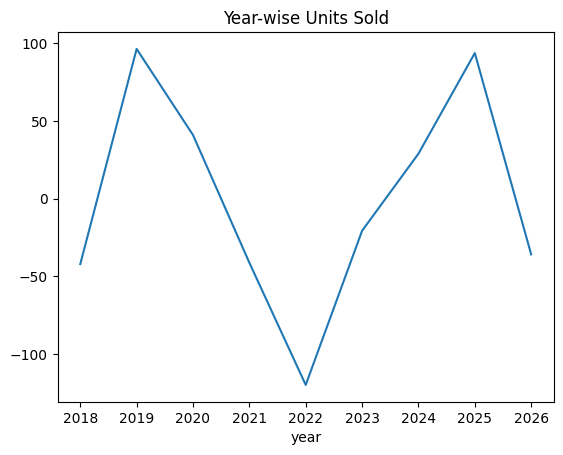

In [ ]:
#13. Analyze the year-wise and month-wise sales trend using appropriate visualizations.
df.groupby("year")["units_sold"].sum().plot(kind="line", title="Year-wise Units Sold")
plt.show()

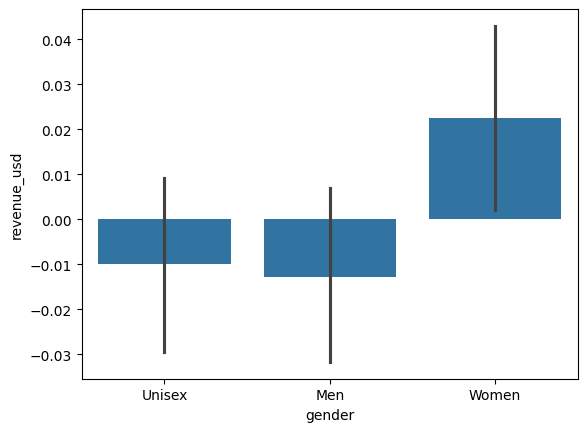

In [ ]:
#14. Compare total revenue and units sold across genders.
sns.barplot(x="gender", y="revenue_usd", data=df)
plt.show()

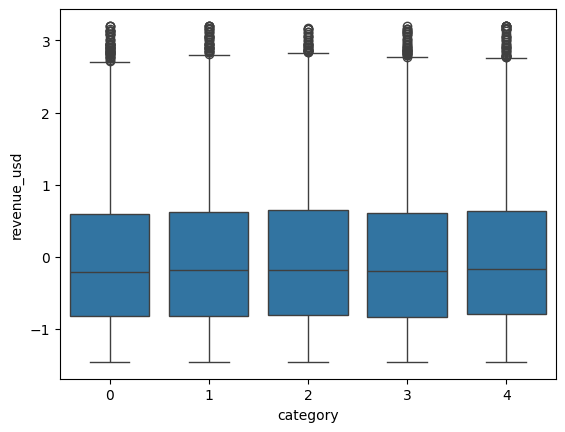

In [ ]:
#15. Study the relationship between product category (Running, Lifestyle, Training, etc.) and revenue.
sns.boxplot(x="category", y="revenue_usd", data=df)
plt.show()

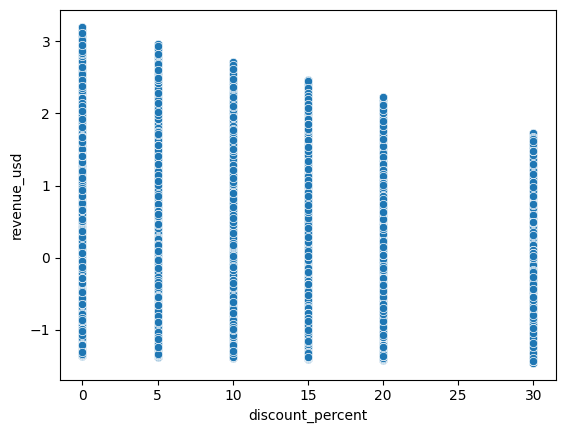

In [ ]:
#16. Analyze how discount percentage affects final sales revenue.
sns.scatterplot(x="discount_percent", y="revenue_usd", data=df)
plt.show()

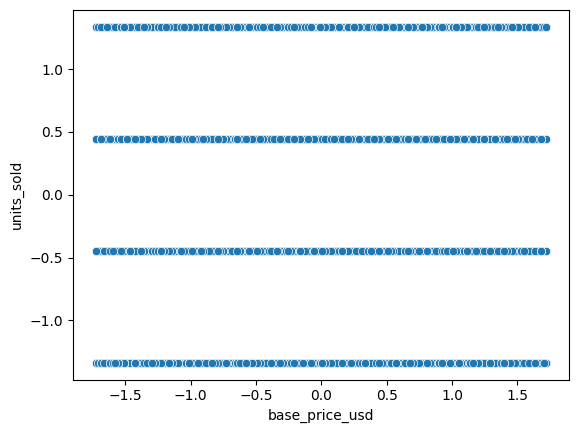

In [ ]:
#17. Examine the impact of base price vs final price on units sold.
sns.scatterplot(x="base_price_usd", y="units_sold", data=df)
plt.show()

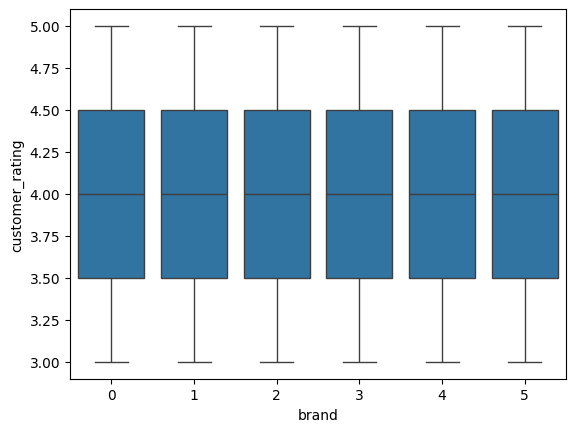

In [ ]:
#18. Compare customer ratings for different brands.
sns.boxplot(x="brand", y="customer_rating", data=df)
plt.show()

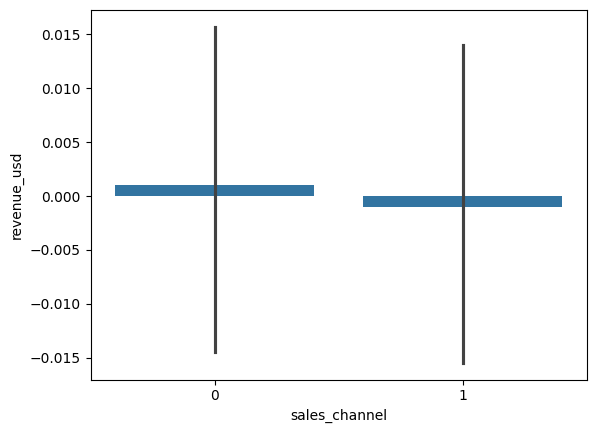

In [ ]:
#19. Analyze how sales channel (Online vs Retail Store) influences revenue and volume.
sns.barplot(x="sales_channel", y="revenue_usd", data=df)
plt.show()

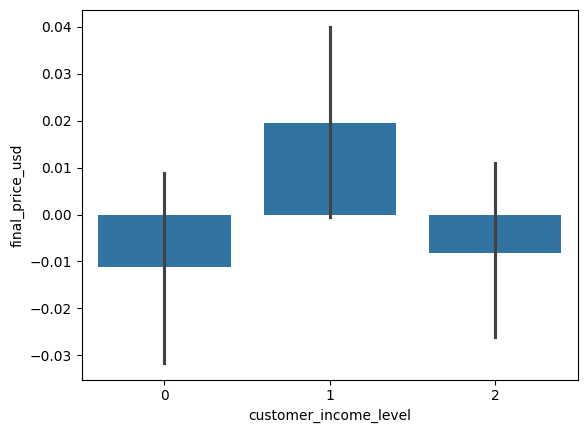

In [ ]:
#20. Study how customer income level affects purchasing behavior and spending.
sns.barplot(x="customer_income_level", y="final_price_usd", data=df)
plt.show()


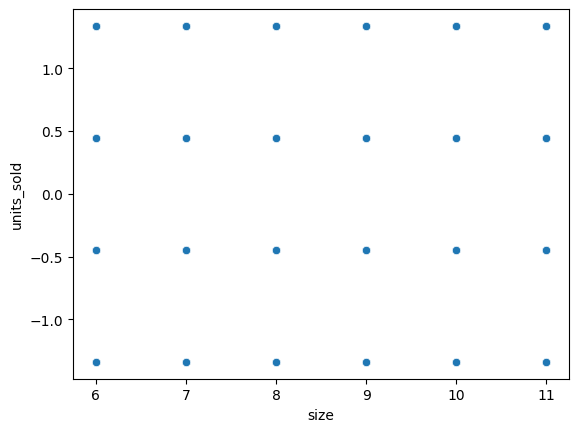

In [ ]:
#21.Evaluate the relationship between shoe size distribution and units sold.
sns.scatterplot(x="size", y="units_sold", data=df)
plt.show()

In [ ]:
#22. Analyze how country-wise sales performance varies across brands.
df.groupby("country")["revenue_usd"].sum().sort_values(ascending=False).head(10)

country
1    56.091829
4     6.518926
0     5.108292
2     4.027631
3   -15.923052
5   -55.823626
Name: revenue_usd, dtype: float64

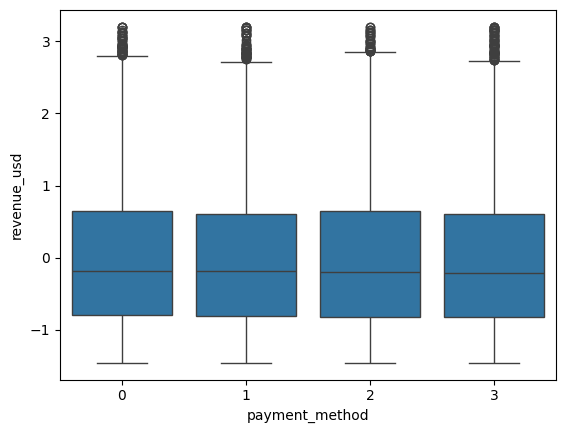

In [ ]:
#23. Study the role of payment method in high-value transactions.
sns.boxplot(x="payment_method", y="revenue_usd", data=df)
plt.show()

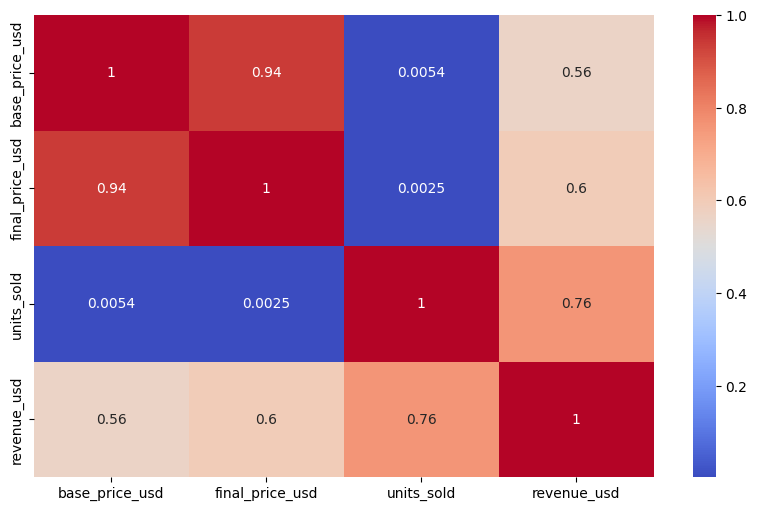

In [ ]:
#24. Create and interpret a correlation heatmap for numerical variables.
plt.figure(figsize=(10,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
plt.show()

In [ ]:
#25. Identify the top 3 most influential features driving revenue or units sold using statistical or ML-based methods.
numeric_df = df[
    [
        "size",
        "base_price_usd",
        "discount_percent",
        "final_price_usd",
        "units_sold",
        "customer_rating",
        "revenue_usd"
    ]
]
correlation_with_target = (
    numeric_df
    .corr()
    ["revenue_usd"]
    .abs()
    .sort_values(ascending=False)
)

correlation_with_target
correlation_with_target[1:4]

units_sold         0.759549
final_price_usd    0.595679
base_price_usd     0.562852
Name: revenue_usd, dtype: float64